<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC-Based Energy Consumption Prediction Using SVR

## SVR Pipeline Summary

- **Goal:** Predict `energy_consumption_current` using EPC Sheffield data.
- **Data preparation:** Removes non-predictive columns and rows with missing target values.
- **Numerical features:** Median imputation + `StandardScaler`.
- **Categorical features:** Most-frequent imputation + one-hot encoding.
- **Dataset:** 10,000-row sample with an **80/20 train-test split**.
- **Model:** SVR with an **RBF kernel**, `C=100`, and `epsilon=0.1`.
- **Performance:**
  - **MAE:** 15.26
  - **RMSE:** 34.07
  - **R²:** 0.9111
- **Overall:** The model explains approximately **91.1% of the variance** in energy consumption.

## Limitations

- **Limited dataset size:** Only a **10,000-row sample** was used because SVR with an RBF kernel can be computationally expensive.
- **Reduced representativeness:** Using a sample rather than the full dataset may not capture all patterns in the EPC data.
- **No hyperparameter tuning:** The SVR parameters (`C=100`, `epsilon=0.1`) appear to be manually specified rather than optimised through cross-validation.
- **Single train-test split:** Performance is based on one **80/20 split**, so results may vary with a different split.
- **Limited model comparison:** The notebook focuses on SVR and does not establish how it performs relative to alternative regression models.
- **No feature selection:** The pipeline does not appear to perform feature selection or dimensionality reduction after preprocessing.
- **Performance assessment is limited:** Evaluation uses MAE, RMSE and R², but there is no additional validation or uncertainty analysis.
- **Computational trade-off:** One-hot encoding combined with SVR can become computationally demanding as the number of categorical levels and observations increases.

## Applicability to Real-World Studies

- **Energy consumption prediction:** The SVR model can be used to predict building energy consumption from EPC property characteristics.
- **Property assessment:** Predictions could support energy-efficiency analysis and comparison across properties.
- **Decision support:** The model may help identify properties with higher expected energy consumption and inform energy-efficiency planning.
- **Scalability:** The current implementation uses a 10,000-row sample, so applying it to larger real-world datasets would require consideration of SVR's computational cost.
- **Generalisation:** The reported performance is promising, but further validation on larger and independent datasets is needed before real-world deployment.
- **Practical use:** The preprocessing pipeline provides a consistent approach for handling missing numerical and categorical data before making predictions.
- **Further development:** Hyperparameter tuning, cross-validation, and comparison with alternative models would strengthen its suitability for real-world applications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# 1. Load data and drop specified non-predictive columns
df = pd.read_csv('EPC_Sheffield_20260414-clean.csv')
cols_to_drop = ['certificate_number', 'postcode', 'constituency_label', 'constituency']
df_model = df.drop(columns=cols_to_drop)

# 2. Define prediction target and feature set
target_col = 'energy_consumption_current'
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

In [3]:
# Remove instances missing the target variable
valid_mask = ~y.isnull()
X, y = X[valid_mask], y[valid_mask]

# Separate feature column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Construct preprocessing pipelines with ColumnTransformer
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

In [4]:
# Subsample dataset for efficient SVM kernel computation
sample_df = df_model.sample(n=10000, random_state=42)
X_sub = sample_df.drop(columns=[target_col])
y_sub = sample_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

# 4. Fit Support Vector Regression model
model_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=100.0, epsilon=0.1))
])

model_svr.fit(X_train, y_train)
y_pred = model_svr.predict(X_test)

# Model Performance Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 15.26
Root Mean Squared Error (RMSE): 34.07
R² Score: 0.9111


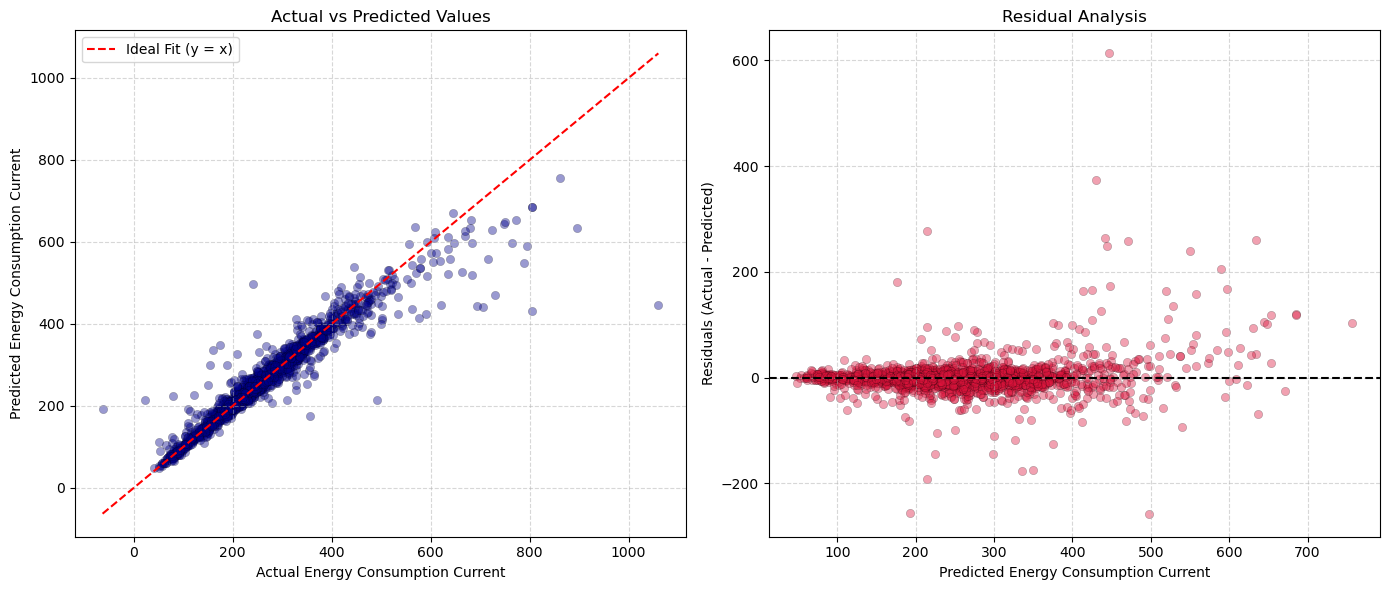

In [5]:
# 5. Visualisations to Evaluate Model
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Actual vs. Predicted Values
axes[0].scatter(y_test, y_pred, alpha=0.4, color='darkblue', edgecolors='k', linewidth=0.3)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit (y = x)')
axes[0].set_xlabel('Actual Energy Consumption Current')
axes[0].set_ylabel('Predicted Energy Consumption Current')
axes[0].set_title('Actual vs Predicted Values')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Residuals Analysis
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='crimson', edgecolors='k', linewidth=0.3)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Energy Consumption Current')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Analysis')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Model Diagnostic Summary

- **Residual Distribution (Histogram & KDE):**
  - Checks whether prediction errors are symmetric and centered around zero.
  - Most residuals are close to zero, indicating accurate predictions.
  - A slight right skew suggests occasional under-prediction for properties with very high energy consumption.

- **Q-Q Plot:**
  - Assesses whether residuals follow a normal distribution.
  - Residuals closely follow the theoretical normal line in the center.
  - Deviations in the upper tail indicate non-normal behaviour for heavy energy users.

- **Permutation Feature Importance:**
  - Measures how much model performance decreases when individual features are randomly shuffled.
  - `current_energy_efficiency`, `total_floor_area`, and `heating_cost_current` are the most influential features for predicting current energy consumption.

- **Category Error Boxplot:**
  - Evaluates prediction consistency across EPC rating groups (A–G).
  - Errors are generally low and stable for ratings **A–D**.
  - Ratings **F–G** show substantially greater prediction variance, indicating that low-efficiency properties are harder for the model to predict accurately.

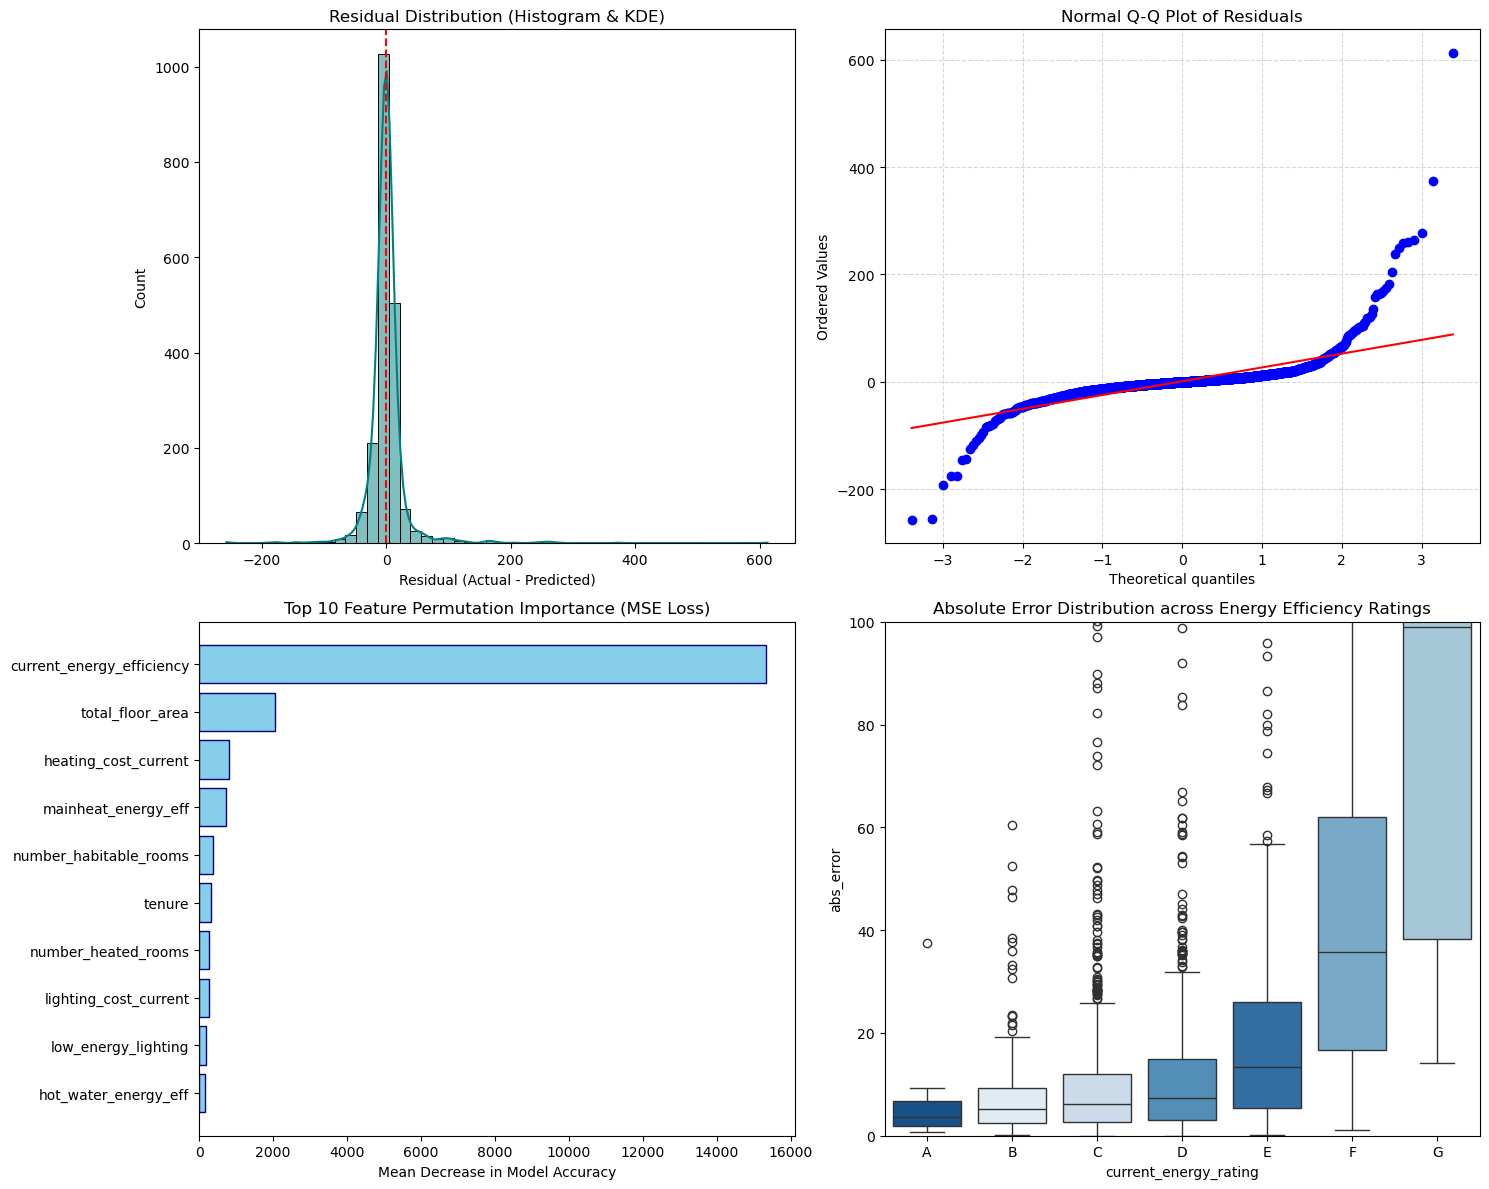

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.inspection import permutation_importance

# 1. Residual Distribution (Histogram & Kernel Density Estimate)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(residuals, kde=True, ax=axes[0,0], color='teal', bins=50)
axes[0,0].set_title('Residual Distribution (Histogram & KDE)')
axes[0,0].set_xlabel('Residual (Actual - Predicted)')
axes[0,0].axvline(0, color='red', linestyle='--')

# 2. Normal Quantile-Quantile (Q-Q) Plot
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot of Residuals')
axes[0,1].grid(True, linestyle='--', alpha=0.5)

# 3. Permutation Feature Importance Plot
perm_importance = permutation_importance(model_svr, X_test, y_test, n_repeats=5, random_state=42, scoring='neg_mean_squared_error')
top_idx = perm_importance.importances_mean.argsort()[-10:]
axes[1,0].barh(X.columns[top_idx], perm_importance.importances_mean[top_idx], color='skyblue', edgecolor='navy')
axes[1,0].set_title('Top 10 Feature Permutation Importance (MSE Loss)')
axes[1,0].set_xlabel('Mean Decrease in Model Accuracy')

# 4. Error Distribution across Sub-categories (Box Plot)
test_data = X_test.copy()
test_data['abs_error'] = np.abs(residuals)
order = sorted(test_data['current_energy_rating'].dropna().unique())
sns.boxplot(
    data=test_data, 
    x='current_energy_rating', 
    y='abs_error', 
    order=order, 
    ax=axes[1,1], 
    hue='current_energy_rating', 
    palette='Blues', 
    legend=False
)
axes[1,1].set_title('Absolute Error Distribution across Energy Efficiency Ratings')
axes[1,1].set_ylim(0, 100)

plt.tight_layout()
plt.show()